In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks
from scipy.stats import circmean
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

In [18]:

#IMAGE_PATH = "../databases/luomus_pictures_1/8/F.8368.jpg"  
IMAGE_PATH =  "C:\\Users\\tombe\\Documents\\_MLE\\CV-for-GRIT\\models\\ruler_detection\\Lepidoptera.jpg"

GRADUATION_MM = 1.0 

MIN_FREQ_RATIO = 0.005        
MAX_FREQ_RATIO = 0.1    
PEAK_PROMINENCE = 0.1 

N_LINES = None        

print(f"Expected gradation : {GRADUATION_MM} mm")
print(f"Valid period spectrum : [{MIN_FREQ_RATIO} – {MAX_FREQ_RATIO}]")

Expected gradation : 1.0 mm
Valid period spectrum : [0.005 – 0.1]


Image size : 7360 × 4912 px


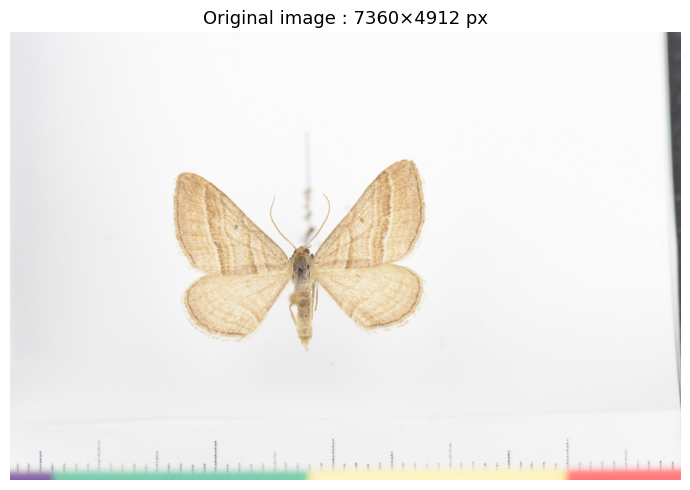

In [19]:
def load_image(path: str) -> tuple[np.ndarray, np.ndarray]:
    img = Image.open(path).convert("RGB")
    img_color = np.array(img)

    img_gray = np.dot(img_color[..., :3], [0.299, 0.587, 0.114]).astype(np.float32) / 255.0

    print(f"Image size : {img_gray.shape[1]} × {img_gray.shape[0]} px")
    return img_gray, img_color


base_img_gray, base_img_color = load_image(IMAGE_PATH)

ruler_ratio = 0

img_gray = base_img_gray[int(ruler_ratio*base_img_gray.shape[0]):, :]
img_color = base_img_color[int(ruler_ratio*base_img_color.shape[0]):, :, :]
H, W = img_gray.shape

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(base_img_color)
ax.set_title(f"Original image : {W}×{H} px", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

In [20]:
def fft_dominant_frequency(row: np.ndarray,
                            min_period_ratio: float,
                            max_period_ratio: float,
                            prominence: float) -> tuple[float | None, float | None]:
    """
    Applique la FFT sur une ligne de pixels et retourne
    la période dominante (en px) et sa phase.

    Paramètres
    ----------
    row           : 1D array de niveaux de gris
    min_period_px : période minimale acceptée (px)
    max_period_px : période maximale acceptée (px)
    prominence    : proéminence relative minimale du pic

    Retourne
    --------
    (période_px, phase_rad) ou (None, None) si aucun pic valide
    """
    N = len(row)

    row_centered = row - row.mean()

    window = np.hanning(N)
    row_windowed = row_centered * window

    fft_vals = np.fft.rfft(row_windowed)
    freqs    = np.fft.rfftfreq(N)   # fréquences normalisées [0, 0.5]

    magnitude = np.abs(fft_vals)

    f_min = 1.0 / (max_period_ratio * N)
    f_max = 1.0 / (min_period_ratio * N)

    mask = (freqs >= f_min) & (freqs <= f_max)
    if mask.sum() == 0:
        return None, None

    mag_masked = magnitude.copy()
    mag_masked[~mask] = 0

    peaks, props = find_peaks(mag_masked,
                              prominence=prominence * mag_masked.max())
    if len(peaks) == 0:
        return None, None

    best_peak = peaks[np.argmax(mag_masked[peaks])]

    period_px = 1.0 / freqs[best_peak]
    phase_rad = np.angle(fft_vals[best_peak])

    return period_px, phase_rad, max(mag_masked[peaks])


row_indices = np.arange(H)
if N_LINES is not None and N_LINES < H:
    row_indices = np.linspace(0, H - 1, N_LINES, dtype=int)

results = []   

for i in row_indices:
    row = img_gray[i, :]
    period, phase, magnitude = fft_dominant_frequency(
        row, MIN_FREQ_RATIO, MAX_FREQ_RATIO, PEAK_PROMINENCE
    )
    if period is not None:
        results.append((i, period, phase, magnitude))

print(f"analysed lines: {len(row_indices)}")
print(f"valid peak lines: {len(results)} ({100*len(results)/len(row_indices):.1f}%)")

analysed lines: 4912
valid peak lines: 4912 (100.0%)


Max magnitude : 96.56
dominant period : 566.15 px -> 566.15 px / mm


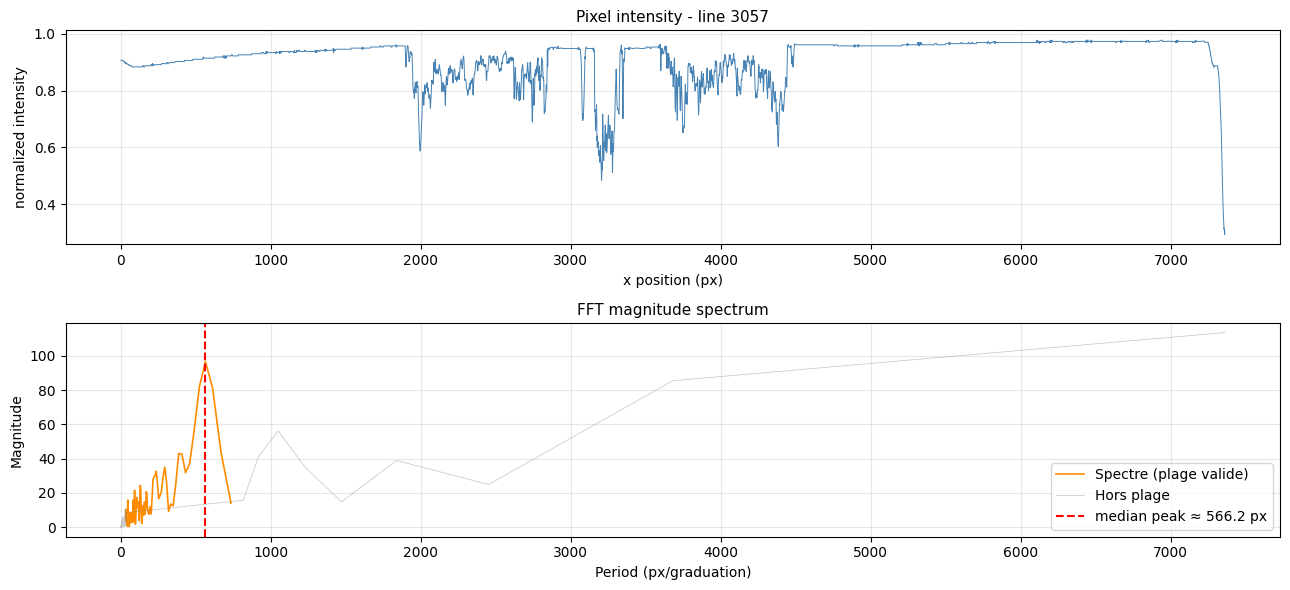

In [21]:

mag_max = 0
max_idx = 0
for i in range(len(results)):
    mid_row  = results[i][0]
    if results[i][3] > mag_max:
        mag_max = results[i][3]
        max_idx = i

mid_row = results[max_idx][0]
row_demo = img_gray[mid_row, :]
N        = len(row_demo)

row_c = row_demo - row_demo.mean()
row_w = row_c * np.hanning(N)
fft_demo  = np.fft.rfft(row_w)
freqs_demo = np.fft.rfftfreq(N)
mag_demo  = np.abs(fft_demo)

with np.errstate(divide='ignore'):
    periods_demo = np.where(freqs_demo > 0, 1.0 / freqs_demo, np.inf)

valid_mask = (periods_demo >= N * MIN_FREQ_RATIO) & (periods_demo <= N * MAX_FREQ_RATIO)

fig, axes = plt.subplots(2, 1, figsize=(13, 6))

axes[0].plot(row_demo, color='steelblue', lw=0.7)
axes[0].set_title(f"Pixel intensity - line {mid_row}", fontsize=11)
axes[0].set_xlabel("x position (px)")
axes[0].set_ylabel("normalized intensity")
axes[0].grid(True, alpha=0.3)

axes[1].plot(periods_demo[valid_mask], mag_demo[valid_mask],
             color='darkorange', lw=1.2, label='Spectre (plage valide)')
axes[1].plot(periods_demo[~valid_mask & (freqs_demo > 0)],
             mag_demo[~valid_mask & (freqs_demo > 0)],
             color='gray', lw=0.6, alpha=0.4, label='Hors plage')

if len(results) > 0:
    dominant_period = periods_demo[valid_mask][np.argmax(mag_demo[valid_mask])]
    print(f"Max magnitude : {mag_demo[valid_mask].max():.2f}")
    print(f"dominant period : {dominant_period:.2f} px -> {dominant_period:.2f} px / mm")
    axes[1].axvline(dominant_period, color='red', ls='--', lw=1.5,
                    label=f'median peak ≈ {dominant_period:.1f} px')

axes[1].set_title("FFT magnitude spectrum", fontsize=11)
axes[1].set_xlabel("Period (px/graduation)")
axes[1].set_ylabel("Magnitude")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Rough median period : 566.154 px
Phase slope (rad/px) : -0.000213

Estimated inclination angle : -1.102°


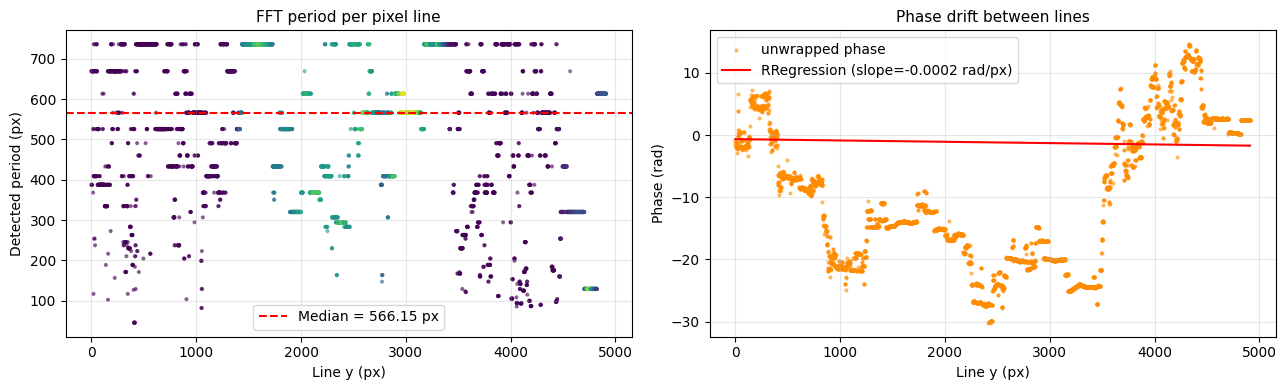

In [22]:
if len(results) < 5:
    raise RuntimeError("Error : not enough valid line")

rows_arr   = np.array([r[0] for r in results], dtype=float)
phases_arr  = np.array([r[2] for r in results], dtype=float)
mag_arr = np.array([r[3] for r in results], dtype=float)

periods_arr = np.array([r[1] for r in results], dtype=float)
max_mag = max(mag_arr)
filtered_rows = []
filtered_phases = []
filtered_periods = []
for i in range(len(results)):
    if results[i][3] == max_mag:
        filtered_rows.append(results[i][0])
        filtered_phases.append(results[i][2])
        filtered_periods.append(results[i][1])
filtered_rows_arr = np.array(filtered_rows, dtype=float)
filtered_phases_arr = np.array(filtered_phases, dtype=float)
filtered_periods_arr = np.array(filtered_periods, dtype=float)


T_median = np.median(filtered_periods_arr)
print(f"Rough median period : {T_median:.3f} px")

phases_unwrapped = np.unwrap(filtered_phases_arr)


slope_phase, intercept_phase = np.polyfit(filtered_rows_arr, phases_unwrapped, 1)

print(f"Phase slope (rad/px) : {slope_phase:.6f}")

tan_theta = slope_phase * T_median / (2 * np.pi)
theta_rad = np.arctan(tan_theta)
theta_deg = np.degrees(theta_rad)

print(f"\nEstimated inclination angle : {theta_deg:.3f}°")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(rows_arr, periods_arr, s=4, alpha=0.5, c=[res[3] for res in results], cmap='viridis',)
axes[0].axhline(T_median, color='red', ls='--', lw=1.5,
                label=f'Median = {T_median:.2f} px')
axes[0].set_title("FFT period per pixel line", fontsize=11)
axes[0].set_xlabel("Line y (px)")
axes[0].set_ylabel("Detected period (px)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(rows_arr, np.unwrap(phases_arr), s=4, alpha=0.5, color='darkorange',
                label='unwrapped phase')
y_fit = slope_phase * rows_arr + intercept_phase
axes[1].plot(rows_arr, y_fit, color='red', lw=1.5,
             label=f'RRegression (slope={slope_phase:.4f} rad/px)')
axes[1].set_title("Phase drift between lines", fontsize=11)
axes[1].set_xlabel("Line y (px)")
axes[1].set_ylabel("Phase (rad)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
T_corrected = T_median / np.cos(theta_rad)

px_per_mm = T_corrected / GRADUATION_MM
mm_per_px = GRADUATION_MM / T_corrected


print(f"Ruler gradation : {GRADUATION_MM:.2f} mm")
print(f"Raw period (X-axis): {T_median:.3f} px")
print(f"Inclination angle: {theta_deg:.3f} °")
print(f"Corrected period: {T_corrected:.3f} px")

print(f"px / mm: {px_per_mm:.4f} px/mm")
print(f"mm / px: {mm_per_px:.6f} mm/px")


Ruler gradation : 1.00 mm
Raw period (X-axis): 566.154 px
Inclination angle: -1.102 °
Corrected period: 566.259 px
px / mm: 566.2585 px/mm
mm / px: 0.001766 mm/px


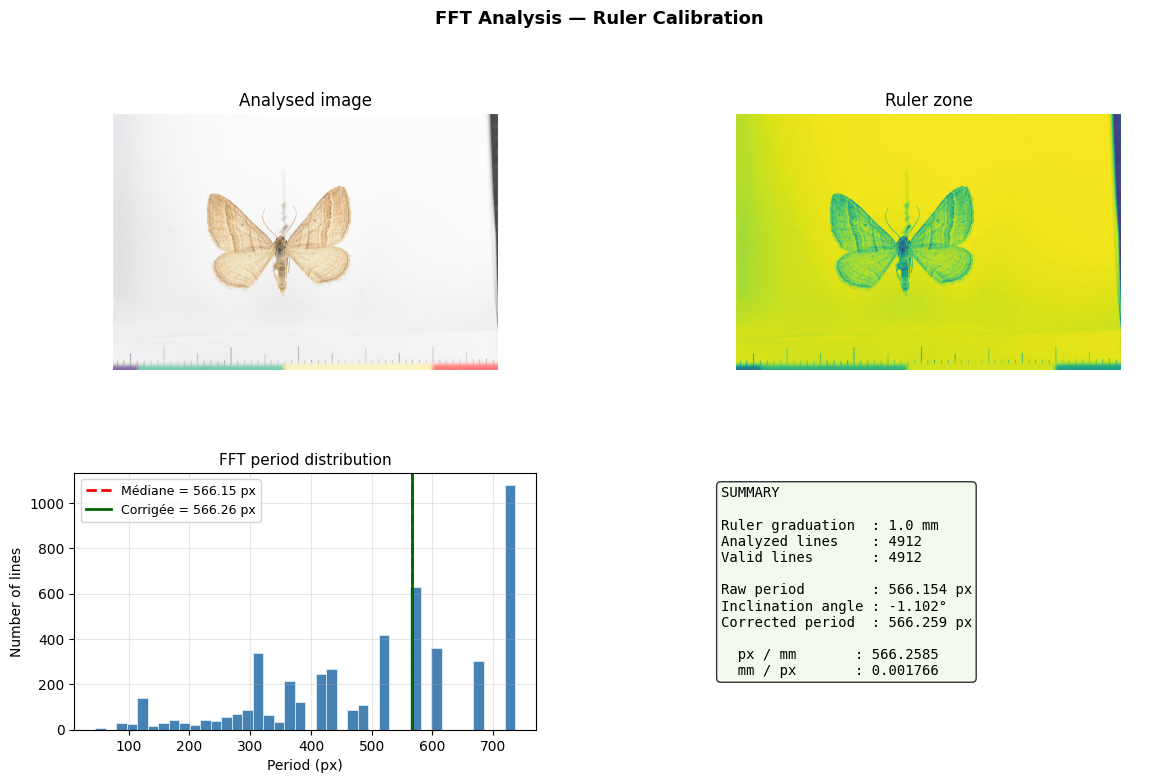

In [24]:

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(base_img_color)
ax1.set_title("Analysed image", fontsize=12)
ax1.axis('off')

info = (f"  mm/px = {mm_per_px:.5f}  |  px/mm = {px_per_mm:.3f}  "
        f"|  angle = {theta_deg:.2f}°  ")
ax1.set_xlabel(info, fontsize=10, labelpad=6)
ax1.xaxis.label.set_color('darkgreen')

ax4 = fig.add_subplot(gs[0, 1])
ax4.imshow(img_gray)
ax4.set_title("Ruler zone", fontsize=12)
ax4.axis('off')

info = (f"  mm/px = {mm_per_px:.5f}  |  px/mm = {px_per_mm:.3f}  "
        f"|  angle = {theta_deg:.2f}°  ")
ax4.set_xlabel(info, fontsize=10, labelpad=6)
ax4.xaxis.label.set_color('darkgreen')

ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(periods_arr, bins=40, color='steelblue', edgecolor='white', lw=0.4)
ax2.axvline(T_median, color='red', ls='--', lw=2,
            label=f'Médiane = {T_median:.2f} px')
ax2.axvline(T_corrected, color='darkgreen', ls='-', lw=2,
            label=f'Corrigée = {T_corrected:.2f} px')
ax2.set_title("FFT period distribution", fontsize=11)
ax2.set_xlabel("Period (px)")
ax2.set_ylabel("Number of lines")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
summary_lines = [
    "SUMMARY",
    "",
    f"Ruler graduation  : {GRADUATION_MM} mm",
    f"Analyzed lines    : {len(row_indices)}",
    f"Valid lines       : {len(results)}",
    "",
    f"Raw period        : {T_median:.3f} px",
    f"Inclination angle : {theta_deg:.3f}°",
    f"Corrected period  : {T_corrected:.3f} px",
    "",
    f"  px / mm       : {px_per_mm:.4f}",
    f"  mm / px       : {mm_per_px:.6f}",
]
summary_text = "\n".join(summary_lines)
ax3.text(0.05, 0.95, summary_text,
         transform=ax3.transAxes,
         fontsize=10, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f8e8', alpha=0.8))

plt.suptitle("FFT Analysis — Ruler Calibration",
             fontsize=13, fontweight='bold', y=1.01)
plt.show()
